In [56]:
import mp_api
import pandas as pd
from mp_offline.client import MPOffline, MaterialSummary
from pymatgen.core.composition import Composition
from pymatgen.core import Structure
from tqdm.auto import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
from monty.serialization import loadfn
from copy import deepcopy

## Loading from the MP dataset

In [2]:
client = MPOffline()
objs = client.query_all(MaterialSummary.energy_above_hull < 0.01)

In [3]:
records = []
for (obj, ) in objs:
    record = {}
    structure = Structure.from_dict(obj.structure)
    record['composition'] = structure.composition
    record['# comp'] = structure.composition
    record['gap'] = obj.json_data['band_gap']
    record['band_gap'] = obj.json_data['band_gap']
    record['nelems'] = len(record['composition'])
    record['reduced_composition'] = record['composition'].get_reduced_composition_and_factor()[0]
    record['# comp'] =  record['reduced_composition']
    record['e_form'] = obj.formation_energy_per_atom
    record['e_hull'] = obj.energy_above_hull
    record['vol'] = structure.volume
    record['nsites'] = obj.nsites
    record['reduced_form'] = structure.composition.reduced_formula
    record['material_id'] = obj.material_id
    record['structure'] = structure
    record['e'] = obj.nsites * obj.energy_per_atom
    records.append(record)
df_mp = pd.DataFrame.from_records(records).set_index('material_id')

/home/bonan/miniconda3/envs/work/lib/python3.10/site-packages/pymatgen/core/composition.py:1337: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  syms = sorted(sym_amt, key=lambda x: [get_el_sp(x).X, x])
/home/bonan/miniconda3/envs/work/lib/python3.10/site-packages/pymatgen/core/composition.py:1337: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  syms = sorted(sym_amt, key=lambda x: [get_el_sp(x).X, x])
/home/bonan/miniconda3/envs/work/lib/python3.10/site-packages/pymatgen/core/composition.py:1337: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  syms = sorted(sym_amt, key=lambda x: [get_el_sp(x).X, x])


In [57]:
valence_mp = loadfn('mp_id_with_valence.json')
df_mp_backup = df_mp
df_mp = df_mp_backup.loc[valence_mp]

Steps

1. Prepare the data
2. Select materials that are binary/ternary
3. Form groups based on composition
4. Form groups based on local geometry
5. Filter by volume changes and band gaps
6. Form the final candidates for calculation

## Loading data from the WBM dataset

In [5]:
from importlib import reload
import datacollect
reload(datacollect)

# df_all = datacollect.load_wbm_data('wbm-dataset', 'wbm-dataset')

<module 'datacollect' from '/home/bonan/work/HC/pair-screening/datacollect.py'>

Select binary structure that are close to the convex hull and have small PBE band gap

In [6]:
from pickle import load

with open('wbm-dataset.df', 'rb') as fp:
    df_wbm = load(fp)

In [121]:
valence_wbm = loadfn('wbm_id_with_valence.json')
df_wbm_backup = df_wbm
df_wbm = df_wbm_backup.loc[valence_wbm]

In [122]:
df_all = pd.concat([df_wbm, df_mp], axis=0)

In [123]:
df_t = df_all.loc[(df_all['nelems'] == 2)   # Take binary materials
            & (df_all.e_hull <= 0.0) 
            & (df_all['band_gap'] < 1), :]

In [124]:
df_t.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2471 entries, wbm-79 to mp-471
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   # comp               2471 non-null   object 
 1   nsites               2471 non-null   int64  
 2   vol                  2471 non-null   float64
 3   e                    2471 non-null   float64
 4   e_form               2471 non-null   float64
 5   e_hull               2471 non-null   float64
 6   gap                  2471 non-null   float64
 7   reduced_form         2471 non-null   object 
 8   structure            2471 non-null   object 
 9   composition          2471 non-null   object 
 10  band_gap             2471 non-null   float64
 11  nelems               2471 non-null   int64  
 12  reduced_composition  2471 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 270.3+ KB


## Match materials based on compositions

Group material with reduced formula that shares common elements

AxBy -> HxKy

For each existing reduced composition, we have three permutations for the first(to be varied composition).

For each reduced composition, record the ByCz combination

In [125]:

all_fixed_parts = {}
for index, row in df_t.iterrows():
    rd = row.reduced_composition
    elems = list(rd.keys())
    for i in [[0, 1], [1, 0]]:
        # Record the fixed 
        fixed_comp = str(Composition({elems[k]: rd[elems[k]]for k in i[:-1]})) + f'X{int(rd[elems[i[-1]]])}'
        # Record the material ID and the corresponding A element (that may change)
        if fixed_comp in all_fixed_parts:
            all_fixed_parts[fixed_comp].append([index, str(elems[i[-1]]), row.band_gap])
        else:
            all_fixed_parts[fixed_comp] = [[index, str(elems[i[-1]]), row.band_gap]]
all_fixed_parts = {k: v for k, v in all_fixed_parts.items() if len(v) > 1}
print(len(all_fixed_parts))



417


Checking the distribution of the group sizes

(array([270.,  42.,  21.,  29.,  17.,   5.,  11.,   5.,   2.,   2.,   2.,
          2.,   1.,   1.,   1.,   0.,   3.,   1.,   0.,   2.]),
 array([  2. ,   7.3,  12.6,  17.9,  23.2,  28.5,  33.8,  39.1,  44.4,
         49.7,  55. ,  60.3,  65.6,  70.9,  76.2,  81.5,  86.8,  92.1,
         97.4, 102.7, 108. ]),
 <BarContainer object of 20 artists>)

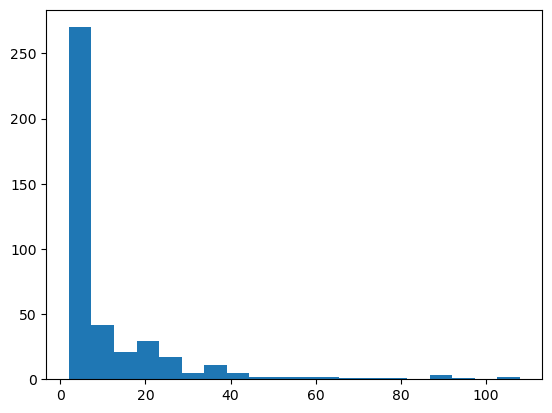

In [126]:
sizes = {k: len(v) for k, v in all_fixed_parts.items()}
plt.hist(list(sizes.values()), bins=20)

In [127]:
counter = Counter(sizes.values())
counter

Counter({2: 90,
         3: 63,
         4: 39,
         5: 37,
         7: 22,
         6: 19,
         9: 13,
         12: 11,
         8: 8,
         10: 6,
         13: 6,
         21: 5,
         20: 5,
         22: 5,
         16: 5,
         19: 5,
         18: 5,
         15: 5,
         34: 4,
         26: 4,
         25: 4,
         23: 4,
         27: 4,
         11: 4,
         44: 3,
         14: 3,
         38: 3,
         24: 3,
         17: 2,
         88: 2,
         29: 2,
         28: 2,
         32: 2,
         35: 2,
         56: 2,
         94: 1,
         45: 1,
         42: 1,
         75: 1,
         62: 1,
         108: 1,
         36: 1,
         103: 1,
         87: 1,
         46: 1,
         37: 1,
         43: 1,
         65: 1,
         31: 1,
         78: 1,
         69: 1,
         52: 1,
         53: 1})

In [128]:
all_fixed_parts

{'Te1X2': [['wbm-79', 'Ag', 0.0],
  ['wbm-80', 'Ag', 0.0],
  ['wbm-193936', 'Ag', 0.54],
  ['mp-1592', 'Ag', 0.0],
  ['mp-582753', 'Tl', 0.6448],
  ['mp-1217269', 'Se', 0.6533000000000002],
  ['mp-21576', 'Sc', 0.0]],
 'Ag2X1': [['wbm-79', 'Te', 0.0],
  ['wbm-80', 'Te', 0.0],
  ['wbm-50347', 'S', 0.6],
  ['wbm-50352', 'S', 0.26],
  ['wbm-52893', 'Se', 0.78],
  ['wbm-52894', 'Se', 0.77],
  ['wbm-52895', 'Se', 0.25],
  ['wbm-52896', 'Se', 0.04],
  ['wbm-52897', 'Se', 0.75],
  ['wbm-52898', 'Se', 0.49],
  ['wbm-52899', 'Se', 0.76],
  ['wbm-52900', 'Se', 0.06],
  ['wbm-52901', 'Se', 0.01],
  ['wbm-193936', 'Te', 0.54],
  ['mp-1592', 'Te', 0.0],
  ['mp-568936', 'Se', 0.0],
  ['mp-353', 'O', 0.0]],
 'Al2X3': [['wbm-924', 'Se', 0.78], ['wbm-62781', 'Se', 0.92]],
 'Se3X2': [['wbm-924', 'Al', 0.78],
  ['wbm-3339', 'As', 0.71],
  ['wbm-3340', 'As', 0.53],
  ['wbm-12384', 'Cr', 0.0],
  ['wbm-29168', 'Mn', 0.0],
  ['wbm-51322', 'Sc', 0.69],
  ['wbm-52653', 'In', 0.61],
  ['wbm-52654', 'In', 0.0],


## Further Match materials based on local environments

The next step

Compare the local environments between the matches based on the composition

The code below uses the robocrystallographer to generate description of the structure. In practice we use a python script and parallel to generate the descriptions of a set of materials

In [129]:
# from robocrys import StructureCondenser, StructureDescriber


# all_condensed = {}
# condenser = StructureCondenser()
# for index, row in tqdm(df_t.iterrows(), total=len(df_t)):
#     ps = row.structure 
#     condensed = condenser.condense_structure(ps)
#     all_condensed[index] = condensed

# dumpfn(all_condensed, 'ternary_condensed.json')

Match strategy:

For each group that we match based on the composition, find the matched structures inside the group

- 

In [130]:
from monty.serialization import loadfn
import numpy as np
from pymatgen.core import Element, Species, Composition

In [131]:
from pathlib import Path
class CondenseLoader:
    
    def __init__(self, basedirs, use_cache=True):
        
        self.basedirs = basedirs
        self.cache = {}
        self.use_cache = use_cache
    
    def get_condensed(self, entry_id):
        
        if self.use_cache and entry_id in self.cache:
            return self.cache[entry_id]
        found = False
        for basedir in self.basedirs:
            path = Path(basedir) / (entry_id + '.json')
            if path.exists():
                obj = loadfn(path)
                found = True
                break
        if not found:
            return None
        if self.use_cache:
            self.cache[entry_id] = obj
        return obj

condense_loader = CondenseLoader(['wbm-dataset/condense/condensed', '../mp-condense/condensed'])
condense_loader.get_condensed('wbm-1')

{'formula': 'Th3Ac',
 'spg_symbol': 'I4/mmm',
 'crystal_system': 'tetragonal',
 'mineral': {'type': 'beta Cu3Ti',
  'distance': 0.27962077800759355,
  'n_species_type_match': True,
  'simplified': False},
 'dimensionality': 3,
 'sites': {'0': {'element': 'Ac0+',
   'geometry': {'type': 'cuboctahedral', 'likeness': 0.9943993501465037},
   'nn': [2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4],
   'nnn': {'face': [0, 4, 4, 4, 2, 2, 4, 2, 2, 0, 4, 4, 0, 2, 2, 2, 2, 0],
    'corner': [4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0],
    'edge': [0,
     0,
     2,
     2,
     0,
     0,
     2,
     2,
     0,
     0,
     2,
     2,
     0,
     0,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2,
     2]},
   'poly_formula': 'Th12',
   'sym_labels': [1]},
  '2': {'element': 'Th0+',
   'geometry': {'type': 'cuboctahedral', 'likeness': 0.6727059271725344},
   'nn': [0, 4, 4, 4, 0, 0, 0, 4, 2, 2, 2, 2],
   'nnn': {'face': [2, 2, 2, 2, 4, 4, 2, 2, 0, 0, 2, 0, 0, 2, 2, 4, 4, 2],
    'edge': [2

In [132]:
import envmatch
reload(envmatch)

<module 'envmatch' from '/home/bonan/work/HC/pair-screening/envmatch.py'>

In [133]:
def get_groups(key, all_fixed_parts):
    """Compute the group and a given set of structure and environments detected"""
    mp_ids = np.array([x[0] for x in all_fixed_parts[key]])
    valid_ids = {}
    for idx in mp_ids:
        output = condense_loader.get_condensed(idx)
        if output is not None:
            valid_ids[idx] = output
    envs = envmatch.find_unique_envs(list(valid_ids.values()))
    groups = envmatch.group_similar_structures(envs, key, np.array(list(valid_ids)))
    for entry in groups:
        entry.band_gaps = [all_fixed_parts[key][i][2] for i in entry.entry_idx]
    return groups

all_groups = [] 
for key in tqdm(all_fixed_parts):
    all_groups.extend(get_groups(key, all_fixed_parts))
# Filter groups that contains only a single X place holder element - likely duplicates
all_groups = [group for group in all_groups if len(np.unique(group.X_element)) > 1]

  0%|          | 0/417 [00:00<?, ?it/s]

Further reduce the valid number of groups

In [134]:
from copy import deepcopy

In [135]:
valid_groups = []
elems = ['U', 'Th', 'Po', 'Tl', 'Hg','Ti', 'Fe', 'Co', 'Ni', 'Mn', 'Cr', 'H', 'V']
elems += ['Dy', 'Sm', 'Eu', 'Gd', 'Tb', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Nd', 'Pm', 'Dy', 'Er']
elems += ['Np', 'Pu', 'Pa', 'Pr']
elems = set(elems)
for group in all_groups:
    new_group = deepcopy(group)
    # Must not contain unwanted elements in the A_elements
    if any(x in group.A_elements[0] for x in elems):
        continue

    # Select entry where the X_element is not the unwanted list of elements
    valid_idx = [idx for idx, value in enumerate(group.X_element) if value not in elems]
    for key in ['entry_idx', 'A_elements', 'compositions', 'X_element', 'mp_ids', 'band_gaps']:
        setattr(new_group, key, [getattr(group, key)[i] for i in valid_idx])
    new_group.group_size = len(new_group.mp_ids)
    # Valid if there are combination of zero and non-zero gaps
    gaps = new_group.band_gaps
    #gap_ok = any(0.5 > x > 0.1 for x in  gaps) and any(x == 0 for x in gaps)
    gap_ok =  any(x == 0 for x in gaps)
    diversity_ok = len(set(new_group.X_element)) > 1
    if len(new_group.mp_ids) > 1 and gap_ok and diversity_ok:
        valid_groups.append(new_group)

In [136]:
print(f'Number of total groups: {len(all_groups)}')
print(f'Number of valid groups: {len(valid_groups)}')

Number of total groups: 568
Number of valid groups: 222


In [137]:
columns = ['entry_idx', 'A_elements', 'compositions', 'X_element', 'mp_ids', 'band_gaps', 'group_size']
data = [
    [getattr(group, col) for col in columns] for group in valid_groups
]
group_df = pd.DataFrame(data, columns=columns).sort_values('group_size', ascending=False)
group_df 

,entry_idx,A_elements,compositions,X_element,mp_ids,band_gaps,group_size
196,"[0, 1, 3, 9, 10, 25, 26, 32, 33, 34, 35, 36, 4...","[[Si], [Si], [Si], [Si], [Si], [Si], [Si], [Si...","[BaSi, CaSi, CeSi, HfSi, LaSi, CeSi, LaSi, ZrS...","[Ba, Ca, Ce, Hf, La, Ce, La, Zr, Ba, Ca, Hf, S...","[wbm-54400, wbm-54489, wbm-54512, wbm-54949, w...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",18
159,"[2, 3, 11, 12, 14, 20, 22, 23, 29, 54, 55, 56,...","[[O], [O], [O], [O], [O], [O], [O], [O], [O], ...","[IrO2, IrO2, PbO2, PbO2, PdO2, RhO2, RhO2, RuO...","[Ir, Ir, Pb, Pb, Pd, Rh, Rh, Ru, Ru, Mo, W, Ru...","[wbm-37083, wbm-37084, wbm-37488, wbm-37489, w...","[0.0, 0.0, 0.13, 0.12, 0.22, 0.0, 0.0, 0.0, 0....",17
144,"[11, 22, 40, 42, 45, 51, 52, 55, 59, 76, 77, 8...","[[N], [N], [N], [N], [N], [N], [N], [N], [N], ...","[HfN, ScN, ZrN, CeN, HfN, YN, LaN, ScN, ZrN, L...","[Hf, Sc, Zr, Ce, Hf, Y, La, Sc, Zr, La, Sc, Hf...","[wbm-31961, wbm-32260, wbm-32432, wbm-159450, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.14, 0.03, 0.0, 0.0...",15
158,"[0, 1, 15, 16, 17, 18, 19, 21, 24, 25, 26, 27,...","[[O], [O], [O], [O], [O], [O], [O], [O], [O], ...","[IrO2, IrO2, RhO2, RhO2, RhO2, RhO2, RhO2, RhO...","[Ir, Ir, Rh, Rh, Rh, Rh, Rh, Rh, Ru, Ru, Ru, R...","[wbm-37081, wbm-37082, wbm-37641, wbm-37642, w...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",14
108,"[1, 2, 3, 16, 20, 21, 23, 32, 46, 58, 76, 77, ...","[[Se], [Se], [Se], [Se], [Se], [Se], [Se], [Se...","[GeSe, GeSe, GeSe, PbSe, PbSe, PbSe, PbSe, ZnS...","[Ge, Ge, Ge, Pb, Pb, Pb, Pb, Zn, Sn, Sn, Pb, L...","[wbm-20072, wbm-20073, wbm-20074, wbm-53019, w...","[0.84, 0.48, 0.07, 0.99, 0.99, 0.8, 0.8, 0.0, ...",14
...,...,...,...,...,...,...,...
120,"[9, 13]","[[Sb], [Sb]]","[CeSb2, LaSb2]","[Ce, La]","[wbm-105409, wbm-180324]","[0.0, 0.0]",2
119,"[35, 36]","[[Sb], [Sb]]","[LaSb2, CeSb2]","[La, Ce]","[mp-1101942, mp-1102986]","[0.0, 0.0]",2
117,"[31, 33]","[[Sb], [Sb]]","[ZrSb2, HfSb2]","[Zr, Hf]","[mp-979, mp-2180]","[0.0, 0.0]",2
116,"[16, 18]","[[Sb], [Sb]]","[LaSb2, CeSb2]","[La, Ce]","[wbm-227126, wbm-252950]","[0.0, 0.0]",2


In [145]:
group_df.to_json('binary-group-df.josn')

Write out the materials that needs to be calculated

In [138]:
all_ids = set()
for value in group_df.mp_ids:
    for k in value:
        all_ids.add(k)
print(f'Total number of materials: {len(all_ids)}')

Total number of materials: 680


In [139]:
from monty.serialization import loadfn, dumpfn

In [140]:
calc_df = df_t.loc[list(all_ids), :].copy()
calc_df['primitive_structure'] = calc_df.structure.apply(lambda x: x.get_primitive_structure())
calc_df['natoms'] = calc_df.primitive_structure.apply(len)

<Axes: xlabel='num_atoms', ylabel='Frequency'>

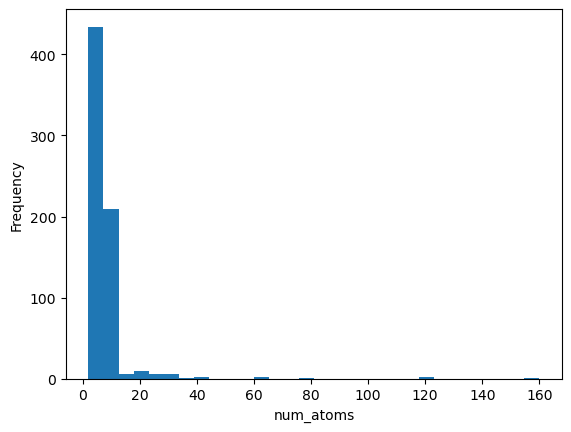

In [141]:
calc_df.natoms.plot.hist(bins=30, xlabel='num_atoms')


In [142]:
calc_df

,# comp,nsites,vol,e,e_form,e_hull,gap,reduced_form,structure,composition,band_gap,nelems,reduced_composition,primitive_structure,natoms
mp-2783,"(Ta, Si)",6,96.244408,-215.480088,-0.594205,0.000,0.0000,Ta2Si,"[[2.14269969 2.59281902 0.62570215] Ta, [-0.80...","(Ta, Si)",0.0000,2,"(Ta, Si)","[[2.14269969 2.59281902 0.62570215] Ta, [-0.80...",6
mp-30999,"(Cu, Cl)",3,68.462596,-25.161751,-0.670026,0.000,0.0000,CuCl2,"[[0. 0. 0.] Cu, [1.21331447 0.77803067 1.76502...","(Cu, Cl)",0.0000,2,"(Cu, Cl)","[[0. 0. 0.] Cu, [1.21331447 0.77803067 1.76502...",3
wbm-44822,OZn,8,81.680000,-35.227000,-1.654000,-0.741,0.7100,ZnO,"[[0. 1.769826 2.50381176] Zn, [ 1.53...","(Zn, O)",0.7100,2,"(Zn, O)","[[-1.53285519 -0.884913 -1.25190588] O, [0. ...",2
mp-2576,"(Sr, Ge)",12,404.308359,-184.098906,-0.620476,0.000,0.3634,Sr2Ge,"[[3.88660992 2.83618538 8.81759942] Sr, [1.295...","(Sr, Ge)",0.3634,2,"(Sr, Ge)","[[3.88660992 2.83618538 8.81759942] Sr, [1.295...",12
wbm-49943,S3Zr2,10,206.510000,-75.085000,-2.011000,-0.051,0.0000,Zr2S3,"[[3.24149167 6.86472517 1.30934596] S, [4.2885...","(S, Zr)",0.0000,2,"(S, Zr)","[[3.24149167 6.86472517 1.30934596] S, [4.2885...",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mp-7088,"(Ta, C)",3,41.503153,-34.735536,-0.591005,0.000,0.0000,Ta2C,[[-1.89744507e-06 1.79838335e+00 1.25408257e...,"(Ta, C)",0.0000,2,"(Ta, C)",[[-1.89744507e-06 1.79838335e+00 1.25408257e...,3
mp-9938,"(Hf, Si)",6,110.833417,-202.899406,-0.791036,0.000,0.0000,Hf2Si,"[[3.37681751 0.86631912 4.54366223] Hf, [4.922...","(Hf, Si)",0.0000,2,"(Hf, Si)","[[3.37681751 0.86631912 4.54366223] Hf, [4.922...",6
wbm-6196,Br2Zr,12,347.750000,-62.863000,-1.303000,-0.030,0.6100,ZrBr2,"[[0. 5.73617342 1.62271949] Br, [1.751...","(Br, Zr)",0.6100,2,"(Br, Zr)","[[0. 5.73617342 1.62271949] Br, [1.751...",12
wbm-12900,Cs3Bi,8,485.440000,-15.617000,-0.306000,-0.104,0.0000,Cs3Bi,"[[3.40595008 1.96642616 0.98272615] Cs, [-3.40...","(Cs, Bi)",0.0000,2,"(Cs, Bi)","[[3.40595008 1.96642616 0.98272615] Cs, [-3.40...",8


## Further Screening
1. must obey the chemical valence rules, or the structure is likely to be metallic hence zero gap

# Save the structures to be calculated

For these structures, we need to compute their MBJ band gaps

Note that we have excluded groups that contains materials only with 0 gap using PBE - this should be lifted later once we are condient of the current search strategy.

In further, the ML predicted (HSE06/experimental) bang gap should be used for screening the groups. 

In [143]:
calc_df = calc_df.loc[calc_df.natoms < 30, :]
print(f'Number of selected structures {len(calc_df)}')

# Structure for MBJ band structure calculation
bg_calc_structures = {index: row.primitive_structure for index, row in calc_df.iterrows()}
dumpfn(bg_calc_structures, 'binary_mbj_calc_structures_2025_03_19.json')

Number of selected structures 665


In [ ]:
.